In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score

In [2]:
results = pd.read_csv("../data/results.csv")

In [3]:
results = results[
    [
        "driverId",
        "grid",
        "points",
        "positionOrder"
    ]
]

results["winner"] = np.where(
    results["positionOrder"] == 1,
    1,
    0
)

driver_stats = (
    results.groupby("driverId")["points"]
    .mean()
    .reset_index()
)

driver_stats.columns = [
    "driverId",
    "avg_driver_points"
]

ml_data = results.merge(
    driver_stats,
    on="driverId",
    how="left"
)

ml_data.head()

,driverId,grid,points,positionOrder,winner,avg_driver_points
0,1,1,10.0,1,1,13.540730
1,2,5,8.0,2,0,1.407609
2,3,7,6.0,3,0,7.740291
3,4,11,5.0,4,0,5.764851
4,5,3,4.0,5,0,0.937500


In [4]:
X = ml_data[
    [
        "grid",
        "points",
        "avg_driver_points"
    ]
]

y = ml_data["winner"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
lr_model = LogisticRegression()

lr_model.fit(
    X_train,
    y_train
)

lr_predictions = lr_model.predict(X_test)

lr_accuracy = accuracy_score(
    y_test,
    lr_predictions
)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.9605754857997011


In [7]:
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt_model.fit(
    X_train,
    y_train
)

dt_predictions = dt_model.predict(X_test)

dt_accuracy = accuracy_score(
    y_test,
    dt_predictions
)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.9945814648729447


In [8]:
print("Logistic Regression :", lr_accuracy)
print("Decision Tree       :", dt_accuracy)

Logistic Regression : 0.9605754857997011
Decision Tree       : 0.9945814648729447


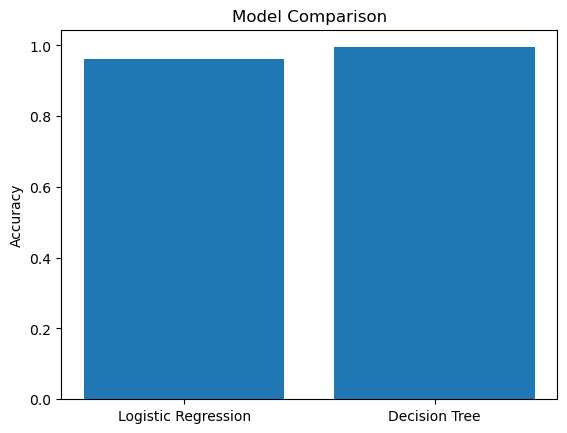

In [9]:
import matplotlib.pyplot as plt

models = [
    "Logistic Regression",
    "Decision Tree"
]

scores = [
    lr_accuracy,
    dt_accuracy
]

plt.bar(
    models,
    scores
)

plt.ylabel("Accuracy")
plt.title("Model Comparison")

plt.show()

# Conclusion

Two machine learning models were trained and compared:

1. Logistic Regression
2. Decision Tree

The comparison shows how different algorithms can produce different results on the same dataset.

Model comparison is an important step in selecting the best machine learning approach for a problem.